In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_deep = pd.read_csv('road_deeplab.csv')
df_sam = pd.read_csv('road_sam.csv')
df_qseg = pd.read_csv('road_qseg.csv')
df_qseg_s = pd.read_csv('road_qseg_sampled.csv')
df_qubo = pd.read_csv('road_qubo.csv')
df = pd.read_csv('road_this_work.csv')

In [3]:
df_runtime = pd.concat([df_deep['Runtime'], df_sam['Runtime'], 
                        df_qseg['Conversion time'], df_qseg['Annealing time'],
                        df_qseg_s['Conversion time'], df_qseg_s['Sampling time'], df_qseg_s['Annealing time'], df_qseg_s['Labeling time'],
                        df_qubo['Conversion time'], df_qubo['Annealing time'], 
                        df['Conversion time'], df['Sampling time'], df['Annealing time'], df['Labeling time']], axis=1)
df_runtime.columns = [
    'Runtime_deeplab',
    'Runtime_sam',
    'Conversion_qseg',
    'Annealing_qseg',
    'Conversion_qseg_s',
    'Sampling_qseg_s',
    'Annealing_qseg_s',
    'Labeling_qseg_s',
    'Conversion_qubo',
    'Annealing_qubo',
    'Conversion_df',
    'Sampling_df',
    'Annealing_df',
    'Labeling_df',
]

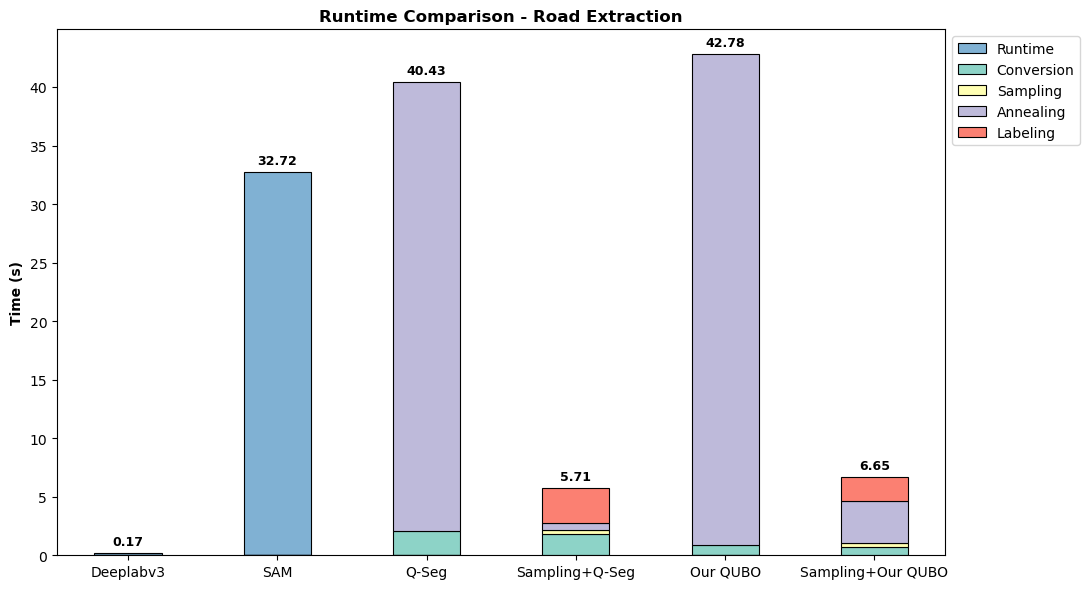

In [4]:
df_runtime = pd.concat(
    {
        "Runtime_deeplab": df_deep["Runtime"],
        "Runtime_sam": df_sam["Runtime"],
        "Conversion_qseg": df_qseg["Conversion time"],
        "Annealing_qseg": df_qseg["Annealing time"],
        "Conversion_qseg_s": df_qseg_s["Conversion time"],
        "Sampling_qseg_s": df_qseg_s["Sampling time"],
        "Annealing_qseg_s": df_qseg_s["Annealing time"],
        "Labeling_qseg_s": df_qseg_s["Labeling time"],
        "Conversion_qubo": df_qubo["Conversion time"],
        "Annealing_qubo": df_qubo["Annealing time"],
        "Conversion_df": df["Conversion time"],
        "Sampling_df": df["Sampling time"],
        "Annealing_df": df["Annealing time"],
        "Labeling_df": df["Labeling time"],
    },
    axis=1,
)

means = df_runtime.mean()

model_keys = ["deeplab", "sam", "qseg", "qseg_s", "qubo", "df"]
op_order = ["Runtime", "Conversion", "Sampling", "Annealing", "Labeling"]
display_labels = {
    "deeplab": "Deeplabv3",
    "sam": "SAM",
    "qseg": "Q-Seg",
    "qseg_s": "Sampling+Q-Seg",
    "qubo": "Our QUBO",
    "df": "Sampling+Our QUBO",
}

plot_data = pd.DataFrame(0.0, index=model_keys, columns=op_order)
for col in df_runtime.columns:
    for op in op_order:
        if col.startswith(op):
            model = col[len(op) :].lstrip("_")
            if model in model_keys:
                plot_data.loc[model, op] = means[col]
            break

plot_data.index = [display_labels[key] for key in plot_data.index]
plot_data = plot_data.loc[:, (plot_data != 0).any(axis=0)]

categories = ["Conversion", "Sampling", "Annealing", "Labeling", "Runtime"]
cmap = plt.colormaps['Set3']
color_map = {cat: cmap(i) for i, cat in enumerate(categories)}
bar_colors = [color_map.get(col, "#333333") for col in plot_data.columns]

fig, ax = plt.subplots(figsize=(11, 6))

plot_data.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=bar_colors,
    width=0.45,
    edgecolor="black",
    linewidth=0.8,
)
totals = plot_data.sum(axis=1)
for i, (model_label, total_val) in enumerate(totals.items()):
    ax.text(
        i,
        total_val + (totals.max() * 0.01),
        f"{total_val:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=9,
    )

plt.title("Runtime Comparison - Road Extraction", fontsize=12, fontweight="bold")
plt.ylabel("Time (s)", fontsize=10, fontweight="bold")
plt.xticks(rotation=0)  
plt.legend(
    bbox_to_anchor=(1.0, 1), loc="upper left"
)
plt.tight_layout()
plt.show()

fig.savefig('road_comp_results.png')

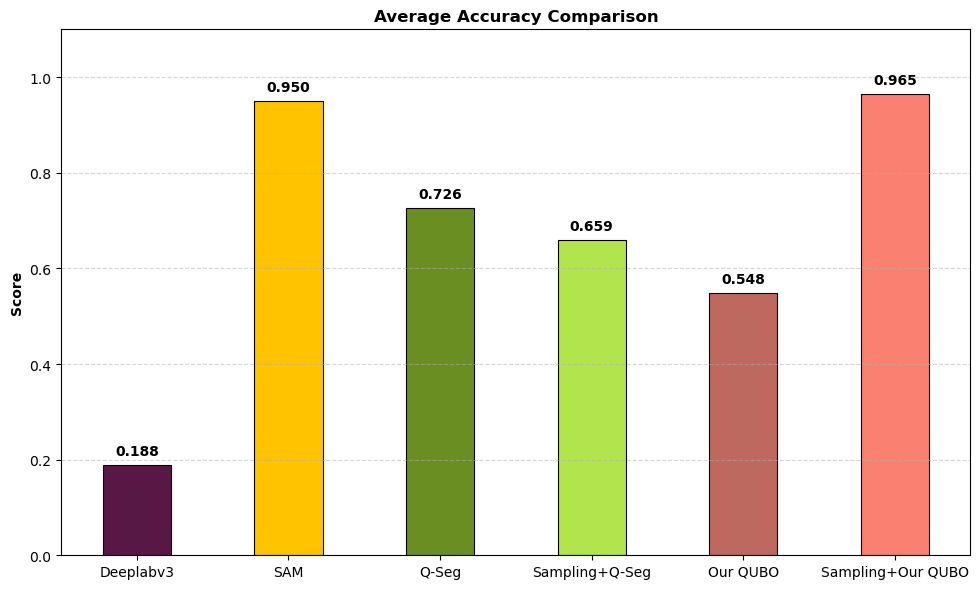

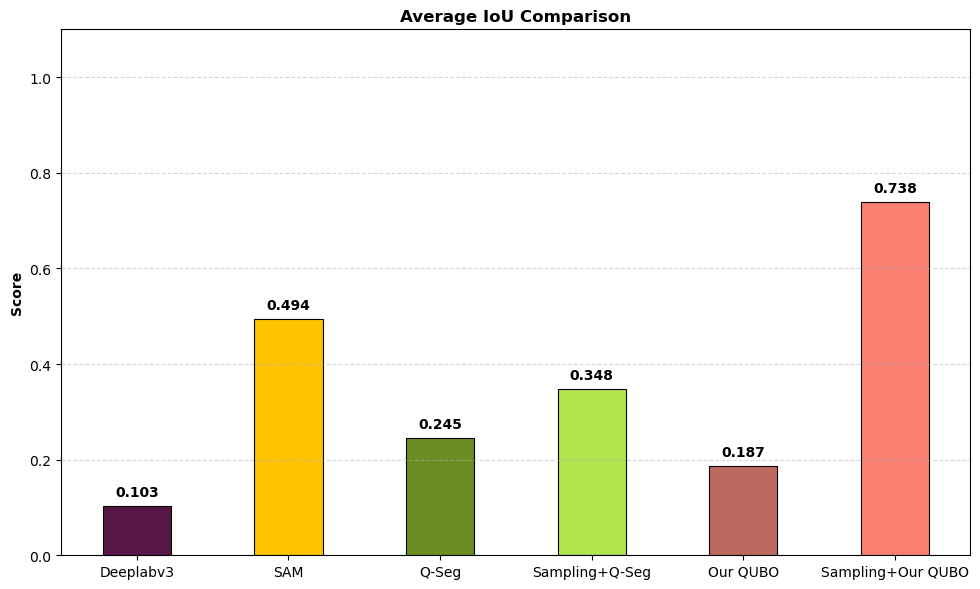

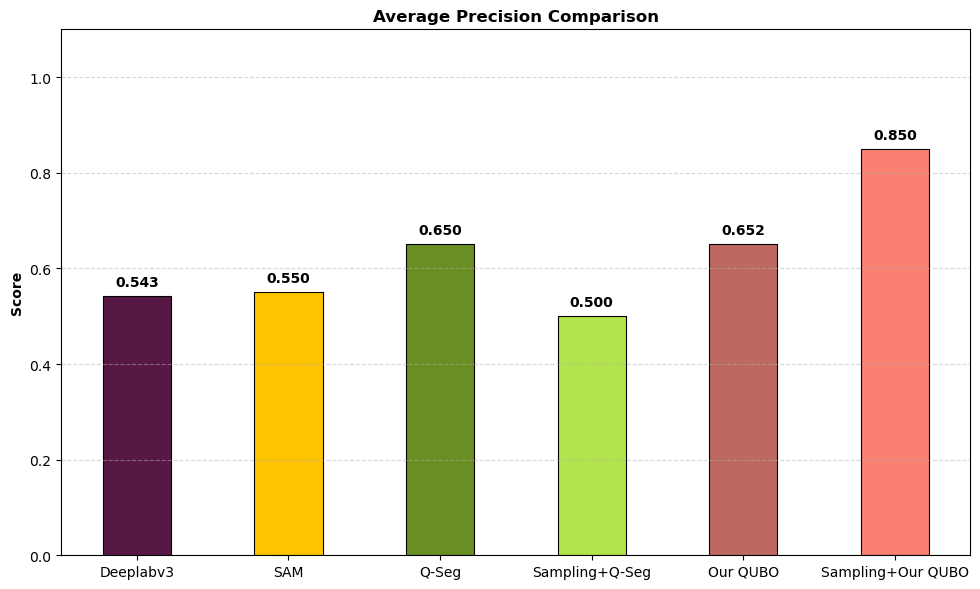

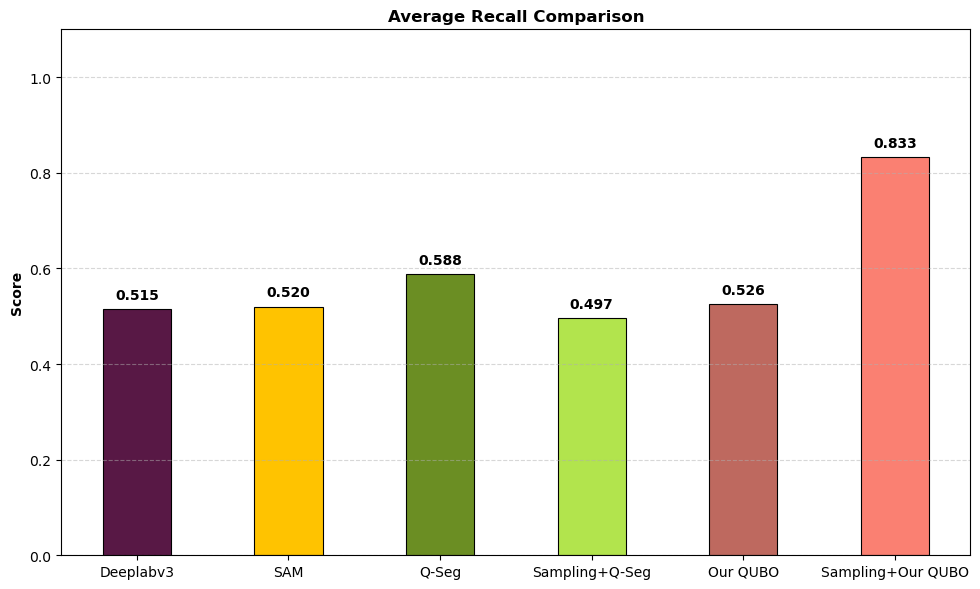

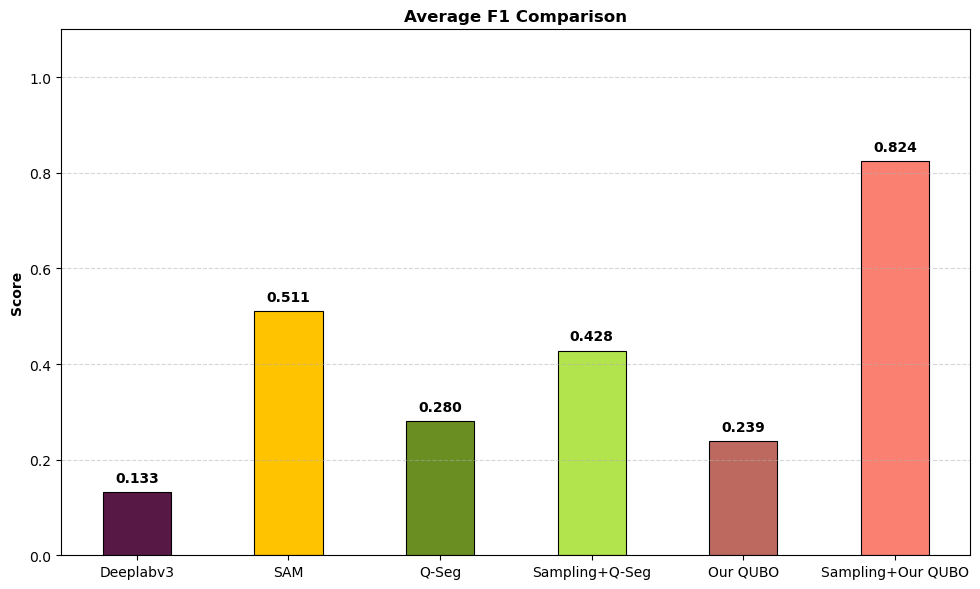

In [5]:
model_dfs = [df_deep, df_sam, df_qseg, df_qseg_s, df_qubo, df]
model_names = [
    'Deeplabv3',
    'SAM',
    'Q-Seg',
    'Sampling+Q-Seg',
    'Our QUBO',
    'Sampling+Our QUBO',
]
distinct_colors = [
    '#581845',  # Deep Plum / Dark Purple
    '#FFC300',  # Bright Gold / Yellow
    "#6B8E23",  # Warm Brown / Terracotta
    "#B2E44D",  # Olive Green
    '#BE695F',  # Steel Blue
    "#FA8072",  # Salmon / Coral
]

metrics = ['Accuracy', 'IoU', 'Precision', 'Recall', 'F1']
for metric in metrics:
    df_metric = pd.concat([d[metric] for d in model_dfs], axis=1)
    df_metric.columns = model_names

    means = df_metric.mean()

    plt.figure(figsize=(10, 6))
    bars = plt.bar(
        means.index,
        means.values,
        color=distinct_colors,
        width=0.45,
        edgecolor='black',
        linewidth=0.8,
    )
    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.015,
            f'{yval:.3f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
        )
    plt.title(f'Average {metric} Comparison', fontsize=12, fontweight='bold')
    plt.ylabel('Score', fontsize=10, fontweight='bold')
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'road_{metric.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()